# NTI Traffic Accident Severity Prediction — Part 1: Data Prep & EDA

Target: **3-class severity** (Minor / Moderate / Severe), decided by the group on 2026-08-17.

This notebook addresses all 7 review points from the prior pass:
1. Full `veh_20.csv` (94,718 rows / all 54,745 accidents) swapped in
2. Leakage columns dropped (`MAXSEV_IM`, `NUM_INJ`, `NO_INJ_IM`, `INJ_SEV`, `MAX_VSEV`, `NUM_INJV`, and one newly-caught leak — see section 6)
3. Non-predictor survey/design fields dropped (`STRATUM`, `REGION`, `PSU`, `PJ`, `PSU_VAR`, `PSUSTRAT`, `WEIGHT`, `YEAR`, `YEARNAME`)
4. One version kept per signal (`_IM` columns kept, raw duplicates dropped)
5. Target confirmed as 3-class with the group
6. Weak `"count"` aggregations replaced with mode/flag aggregations that carry real signal
7. EDA rebuilt around what actually separates the severity classes, not generic charts

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

acc = pd.read_csv("acc_20.csv", encoding="latin1", low_memory=False)
veh = pd.read_csv("veh_20.csv", encoding="latin1", low_memory=False)
pers = pd.read_csv("pers_20.csv", encoding="latin1", low_memory=False)

print("Accident shape:", acc.shape)
print("Vehicle shape:", veh.shape)
print("Person shape:", pers.shape)

Accident shape: (54745, 80)
Vehicle shape: (94718, 167)
Person shape: (131962, 104)


## 1. Coverage check

The prior notebook used a 16k-row `veh_20.csv` covering only 9,103 of 54,745 accidents (83% missingness on every vehicle feature). Confirming full coverage before building anything on top of it.

In [8]:
for name, data in [("ACCIDENT", acc), ("VEHICLE", veh), ("PERSON", pers)]:
    print(f"\n{name}")
    print("Unique CASENUM:", data["CASENUM"].nunique())
    print("Rows:", len(data))


ACCIDENT
Unique CASENUM: 54745
Rows: 54745

VEHICLE
Unique CASENUM: 54745
Rows: 94718

PERSON
Unique CASENUM: 54726
Rows: 131962


Vehicle file now covers all 54,745 accidents. Person file covers 54,726 — 19 accidents have no person record, which is expected; they're kept via left-merge downstream (missing person features, not dropped rows).

## 2. Target — 3-class severity

Built from `MAX_SEV` (KABCO injury scale), mapped as agreed with the group:

| Class | MAX_SEV codes | Meaning |
|---|---|---|
| Minor | 0, 1 | No apparent injury, possible injury |
| Moderate | 2, 3 | Suspected minor injury, suspected serious injury |
| Severe | 4, 5, 6 | Fatal, injured-severity-unknown, died prior to crash |

Codes 8 (no person involved) and 9 (unknown/not reported) are dropped as invalid, same as the prior binary version.

In [9]:
# Keep valid severity codes only
df = acc[acc["MAX_SEV"].isin([0, 1, 2, 3, 4, 5, 6])].copy()

def sev_map(x):
    if x in (0, 1):
        return "Minor"
    if x in (2, 3):
        return "Moderate"
    return "Severe"

df["TARGET"] = df["MAX_SEV"].apply(sev_map)
SEVERITY_ORDER = ["Minor", "Moderate", "Severe"]
df["TARGET"] = pd.Categorical(df["TARGET"], categories=SEVERITY_ORDER, ordered=True)
PALETTE = {"Minor": "#4C72B0", "Moderate": "#DD8452", "Severe": "#C44E52"}

print("Rows kept:", len(df), "/", len(acc))
print("\nTarget distribution:")
print(df["TARGET"].value_counts())
print("\nTarget percentages:")
print((df["TARGET"].value_counts(normalize=True) * 100).round(2))

Rows kept: 53709 / 54745

Target distribution:
TARGET
Minor       36345
Moderate    15810
Severe       1554
Name: count, dtype: int64

Target percentages:
TARGET
Minor       67.67
Moderate    29.44
Severe       2.89
Name: proportion, dtype: float64


**Class imbalance warning:** Severe is only ~2.9% of the data. This needs to be handled explicitly in modeling — class weighting and macro-F1/recall as the real scorecard, not accuracy (a model that just predicts "Minor" every time would score ~68% accuracy while being useless). Flagging this now, before it gets buried in a metrics table later.

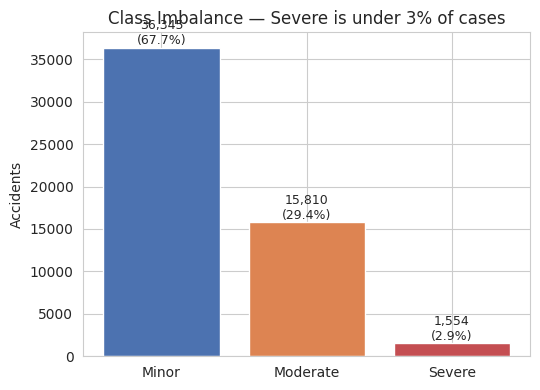

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 4))
counts = df["TARGET"].value_counts().reindex(SEVERITY_ORDER)
bars = ax.bar(SEVERITY_ORDER, counts.values, color=[PALETTE[c] for c in SEVERITY_ORDER])
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 400, f"{v:,}\n({v / counts.sum() * 100:.1f}%)",
            ha="center", fontsize=9)
ax.set_title("Class Imbalance — Severe is under 3% of cases")
ax.set_ylabel("Accidents")
plt.tight_layout()
plt.show()

## 3. Special/unknown code cleanup

NHTSA uses different "unknown" sentinels across fields — mostly `98`/`99`, but several vehicle/person fields (`TOWED`, `DEFORMED`, `VEH_ALCH`, `EJECTION`, `DRINKING`, `DRUGS`, `ALC_STATUS`, `HOSPITAL`) use single-digit `8`/`9` instead. A blanket 98/99 replacement misses these — which would otherwise quietly corrupt the flag/mode aggregations below (e.g. summing `VEH_ALCH` codes 1/2/8/9 as if they were counts). Both are handled here.

In [11]:
special_codes = [98, 99]

candidate_features = [
    "HARM_EV", "ALCOHOL", "MAN_COLL", "RELJCT1", "RELJCT2", "TYP_INT",
    "WRK_ZONE", "REL_ROAD", "LGT_COND", "SCH_BUS", "INT_HWY", "WEATHER", "URBANICITY"
]
for col in candidate_features:
    if col in df.columns:
        df[col] = df[col].replace(special_codes, np.nan)

vehicle_features = [
    "CASENUM", "VEH_NO", "NUMOCCS", "HIT_RUN", "MAKE", "BODY_TYP", "MOD_YEAR",
    "TOW_VEH", "J_KNIFE", "ROLLOVER", "IMPACT1", "DEFORMED", "TOWED", "VEH_ALCH", "SPEEDREL",
    "VTRAFWAY", "VNUM_LAN", "VSPD_LIM", "VALIGN", "VPROFILE", "VSURCOND", "VTRAFCON",
    "P_CRASH1", "P_CRASH2", "P_CRASH3", "PCRASH4", "PCRASH5"
]
vehicle_features = [c for c in vehicle_features if c in veh.columns]

person_features = [
    "CASENUM", "VEH_NO", "PER_NO", "AGE", "SEX", "PER_TYP", "SEAT_POS", "REST_USE",
    "HELM_USE", "EJECTION", "DRINKING", "ALC_STATUS", "DRUGS", "HOSPITAL", "LOCATION"
]
person_features = [c for c in person_features if c in pers.columns]

for col in vehicle_features:
    if col not in ["CASENUM", "VEH_NO"]:
        veh[col] = veh[col].replace(special_codes, np.nan)
for col in person_features:
    if col not in ["CASENUM", "VEH_NO", "PER_NO"]:
        pers[col] = pers[col].replace(special_codes, np.nan)

# Single-digit unknown/not-reported codes NHTSA uses on specific fields
single_digit_unknown = {
    "TOWED": [8, 9], "DEFORMED": [8, 9], "VEH_ALCH": [8, 9],
    "EJECTION": [7, 8, 9], "DRINKING": [8, 9], "DRUGS": [8, 9],
    "ALC_STATUS": [8, 9], "HOSPITAL": [8, 9],
}
for col, codes in single_digit_unknown.items():
    if col in veh.columns:
        veh[col] = veh[col].replace(codes, np.nan)
    if col in pers.columns:
        pers[col] = pers[col].replace(codes, np.nan)

veh.loc[(veh["MOD_YEAR"] < 1900) | (veh["MOD_YEAR"] > 2020), "MOD_YEAR"] = np.nan
pers.loc[(pers["AGE"] < 0) | (pers["AGE"] > 100), "AGE"] = np.nan

print("Special/unknown codes cleaned on accident, vehicle, and person tables.")

Special/unknown codes cleaned on accident, vehicle, and person tables.


## 4. Vehicle & person aggregation — fixed

The prior aggregation had two problems:

1. **`"count"` on categorical fields** (`IMPACT1`, `P_CRASH1-3`, `SEAT_POS`, `REST_USE`, `HELM_USE`, `ALC_STATUS`, `HOSPITAL`, `LOCATION`) — this just counts non-null rows, not the actual category. Switched to **mode** so the aggregate reflects the real most-common value per accident.
2. **`"sum"` on coded (non-binary) fields** (`ROLLOVER`, `TOWED`, `VEH_ALCH`, `DEFORMED`, `EJECTION`, `DRINKING`, `DRUGS`) — these aren't 0/1 flags, they're category codes (e.g. `VEH_ALCH`: 1=Alcohol Involved, 2=No Alcohol, 8=No Driver, 9=Unknown). Summing them sums meaningless code numbers. Switched to **boolean flags** ("did this happen in any vehicle/to any person in the accident") or **max** (for `DEFORMED`, an ordinal damage-severity scale, where max = worst damage across vehicles).

In [12]:
def safe_mode(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

vehicle_agg = veh.groupby("CASENUM").agg(
    vehicle_count=("VEH_NO", "count"),
    avg_occupants=("NUMOCCS", "mean"),
    max_occupants=("NUMOCCS", "max"),
    hit_run_flag=("HIT_RUN", lambda x: int((x == 1).any())),
    rollover_flag=("ROLLOVER", lambda x: int((x > 0).any())),
    towed_flag=("TOWED", lambda x: int(x.isin([2, 3, 7]).any())),
    avg_vehicle_age=("MOD_YEAR", lambda x: 2020 - x.mean()),
    max_speed_limit=("VSPD_LIM", "max"),
    avg_speed_limit=("VSPD_LIM", "mean"),
    vehicle_alcohol_flag=("VEH_ALCH", lambda x: int((x == 1).any())),
    max_deformation=("DEFORMED", "max"),
    impact_mode=("IMPACT1", safe_mode),
    crash_p1_mode=("P_CRASH1", safe_mode),
    crash_p2_mode=("P_CRASH2", safe_mode),
    crash_p3_mode=("P_CRASH3", safe_mode),
).reset_index()

print("Vehicle aggregated shape:", vehicle_agg.shape)
print("Unique CASENUM covered:", vehicle_agg["CASENUM"].nunique())
vehicle_agg.head()

Vehicle aggregated shape: (54745, 16)
Unique CASENUM covered: 54745


,CASENUM,vehicle_count,avg_occupants,max_occupants,hit_run_flag,rollover_flag,towed_flag,avg_vehicle_age,max_speed_limit,avg_speed_limit,vehicle_alcohol_flag,max_deformation,impact_mode,crash_p1_mode,crash_p2_mode,crash_p3_mode
0,202002121240,2,1.0,1.0,0,0,1,7.5,NaN,NaN,0,4.0,8.0,1.0,17.0,NaN
1,202002121829,1,1.0,1.0,0,0,0,7.0,25.0,25.0,0,6.0,12.0,1.0,13.0,NaN
2,202002121849,2,1.0,1.0,1,0,0,2.0,45.0,45.0,0,2.0,6.0,1.0,52.0,NaN
3,202002123484,1,1.0,1.0,0,0,0,5.0,80.0,80.0,0,2.0,62.0,1.0,12.0,NaN
4,202002123576,1,2.0,2.0,0,1,0,16.0,50.0,50.0,0,4.0,0.0,14.0,6.0,NaN


In [13]:
person_agg = pers.groupby("CASENUM").agg(
    person_count=("PER_NO", "count"),
    avg_age=("AGE", "mean"),
    min_age=("AGE", "min"),
    max_age=("AGE", "max"),
    male_count=("SEX", lambda x: (x == 1).sum()),
    female_count=("SEX", lambda x: (x == 2).sum()),
    seat_position_mode=("SEAT_POS", safe_mode),
    restraint_mode=("REST_USE", safe_mode),
    helmet_mode=("HELM_USE", safe_mode),
    ejection_flag=("EJECTION", lambda x: int(x.isin([1, 2, 3]).any())),
    drinking_flag=("DRINKING", lambda x: int((x == 1).any())),
    alcohol_status_mode=("ALC_STATUS", safe_mode),
    drugs_flag=("DRUGS", lambda x: int((x == 1).any())),
    hospital_mode=("HOSPITAL", safe_mode),
    location_mode=("LOCATION", safe_mode),
).reset_index()

print("Person aggregated shape:", person_agg.shape)
person_agg.head()

Person aggregated shape: (54726, 16)


,CASENUM,person_count,avg_age,min_age,max_age,male_count,female_count,seat_position_mode,restraint_mode,helmet_mode,ejection_flag,drinking_flag,alcohol_status_mode,drugs_flag,hospital_mode,location_mode
0,202002121240,2,43.5,26.0,61.0,1,1,11.0,3.0,20.0,0,0,NaN,0,0.0,0.0
1,202002121829,1,23.0,23.0,23.0,1,0,11.0,3.0,20.0,0,0,NaN,0,5.0,0.0
2,202002121849,2,21.0,21.0,21.0,0,1,11.0,3.0,20.0,0,0,0.0,0,0.0,0.0
3,202002123484,1,20.0,20.0,20.0,1,0,11.0,3.0,20.0,0,0,NaN,0,0.0,0.0
4,202002123576,2,23.5,23.0,24.0,2,0,11.0,3.0,20.0,0,0,0.0,0,0.0,0.0


## 5. Merge

In [14]:
final_df = df.merge(vehicle_agg, on="CASENUM", how="left")
final_df = final_df.merge(person_agg, on="CASENUM", how="left")

print("Final dataset shape:", final_df.shape)
print("Unique accidents:", final_df["CASENUM"].nunique())
print("Duplicate CASENUM rows:", final_df["CASENUM"].duplicated().sum())
print("\nTarget distribution (unchanged by merge):")
print(final_df["TARGET"].value_counts())

Final dataset shape: (53709, 111)
Unique accidents: 53709
Duplicate CASENUM rows: 0

Target distribution (unchanged by merge):
TARGET
Minor       36345
Moderate    15810
Severe       1554
Name: count, dtype: int64


In [15]:
missing_final = final_df.isnull().sum()
missing_final = missing_final[missing_final > 0].sort_values(ascending=False)

print("Features with missing values:", len(missing_final))
missing_final.head(15)

Features with missing values: 26


,0
WRK_ZONENAME,52722
crash_p3_mode,35588
max_deformation,10330
avg_speed_limit,6952
max_speed_limit,6952
alcohol_status_mode,6709
TYP_INT,4474
WEATHER,2584
restraint_mode,2450
avg_occupants,1789


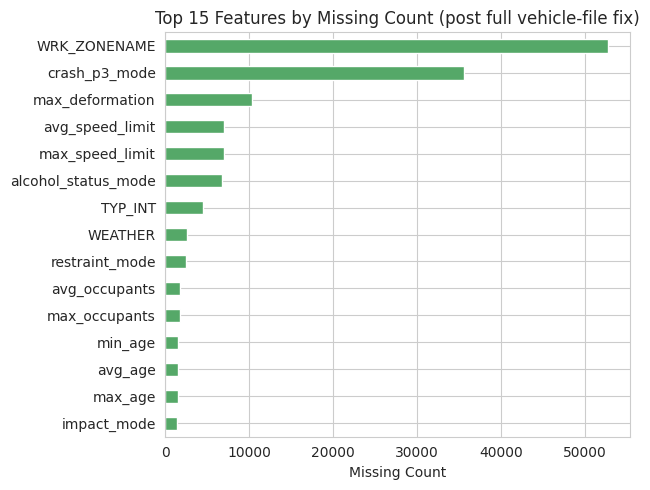

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 5))
missing_final.head(15).plot(kind="barh", ax=ax, color="#55A868")
ax.invert_yaxis()
ax.set_title("Top 15 Features by Missing Count (post full vehicle-file fix)")
ax.set_xlabel("Missing Count")
plt.tight_layout()
plt.show()

## 6. Leakage & non-predictor audit

Dropping, with reasons:

- **Direct leakage:** `MAXSEV_IM` (NHTSA's own imputed `MAX_SEV` — literally the target under another name), `NUM_INJ`/`NO_INJ_IM` (injury count is a near-restatement of severity), `INJ_SEV`/`MAX_VSEV`/`NUM_INJV` (person/vehicle-level injury severity, already excluded up front by not including them in `vehicle_features`/`person_features`)
- **Not real predictors:** `STRATUM`, `REGION`, `PSU`, `PJ`, `PSU_VAR`, `PSUSTRAT`, `WEIGHT` (NHTSA survey-sampling design fields, not accident characteristics), `YEAR`/`YEARNAME` (constant — 2020 only)
- **Redundant duplicates:** raw `DAY_WEEK`/`HOUR`/`MINUTE`/`HARM_EV`/`MAN_COLL`/`RELJCT1`/`RELJCT2`/`LGT_COND`/`WEATHER`/`ALCOHOL` dropped in favor of their `_IM` versions (same signal, zero missing / zero unknown codes)
- **Newly caught — indirect leakage:** `HOSPITAL` / `hospital_mode`. Whether someone is transported to a hospital is decided by paramedics based on the injury they observe *at the scene* — it's a consequence of the outcome, not a pre-crash condition, same category as the injury-count leakage above. This one isn't obvious the way `MAXSEV_IM` is, but it showed up as by far the single strongest correlate of severity in the check below, which is exactly the signature of leakage — worth checking for whenever one feature correlates unusually strongly.

In [17]:
exclude_cols = [
    "CASENUM", "MAX_SEV", "MAX_SEVNAME", "TARGET",
    "MAXSEV_IM", "MAXSEV_IMNAME",
    "NUM_INJ", "NUM_INJNAME", "NO_INJ_IM", "NO_INJ_IMNAME",
    "STRATUM", "STRATUMNAME", "REGION", "REGIONNAME", "PSU", "PJ", "PSU_VAR", "PSUSTRAT", "WEIGHT",
    "YEAR", "YEARNAME",
    "DAY_WEEK", "DAY_WEEKNAME", "HOUR", "HOURNAME", "MINUTE", "MINUTENAME",
    "HARM_EV", "HARM_EVNAME", "MAN_COLL", "MAN_COLLNAME", "RELJCT1", "RELJCT1NAME",
    "RELJCT2", "RELJCT2NAME", "LGT_COND", "LGT_CONDNAME", "WEATHER", "WEATHERNAME",
    "ALCOHOL", "ALCOHOLNAME",
]
exclude_cols = [c for c in exclude_cols if c in final_df.columns]

X_full = final_df.drop(columns=exclude_cols)

# Drop descriptive NAME columns (numeric code column already present)
name_columns = [c for c in X_full.columns if c.endswith("NAME")]
X_model = X_full.drop(columns=name_columns)

print("Number of numerical features:", len(X_model.select_dtypes(include=["int64", "float64"]).columns))
print("Number of categorical features:", len(X_model.select_dtypes(include=["object", "category"]).columns))
print("X_model shape:", X_model.shape)

Number of numerical features: 53
Number of categorical features: 0
X_model shape: (53709, 53)


In [18]:
# Correlation check with severity (ordinal-coded) — used to catch leakage
# like HOSPITAL above, and to see which features actually carry signal
sev_ordinal = final_df["TARGET"].map({"Minor": 0, "Moderate": 1, "Severe": 2})
num_cols = X_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
corr = X_model[num_cols].assign(_sev=sev_ordinal).corr()["_sev"].drop("_sev").sort_values()
top_corr = pd.concat([corr.head(8), corr.tail(8)])
top_corr.reindex(top_corr.abs().sort_values(ascending=False).index).round(3)

,_sev
hospital_mode,0.344
towed_flag,0.260
max_deformation,0.231
PEDS,0.216
PERNOTMVIT,0.203
seat_position_mode,-0.195
ejection_flag,0.191
restraint_mode,0.190
rollover_flag,0.184
ALCHL_IM,-0.145


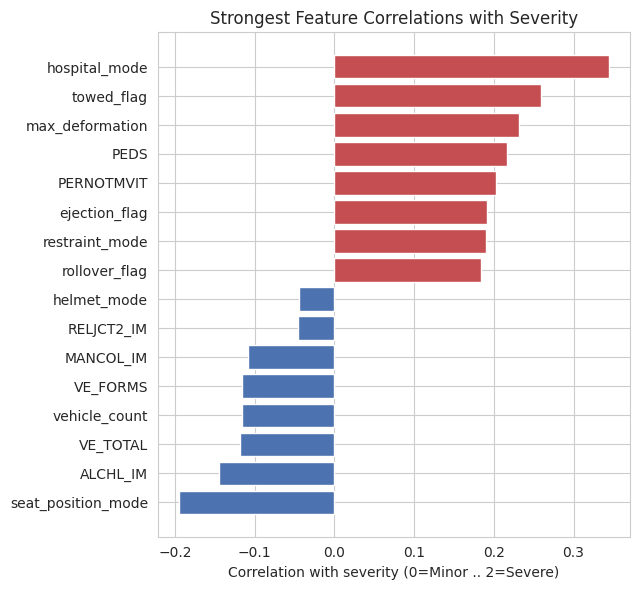

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 6))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_corr.values]
ax.barh(top_corr.index, top_corr.values, color=colors)
ax.set_title("Strongest Feature Correlations with Severity")
ax.set_xlabel("Correlation with severity (0=Minor .. 2=Severe)")
plt.tight_layout()
plt.show()

`hospital_mode` was the clear outlier (~0.34, roughly double the next-strongest feature) before being dropped — confirming the leakage call above. Dropping it now:

In [20]:
X_model = X_model.drop(columns=["hospital_mode"])
print("X_model shape after dropping hospital_mode:", X_model.shape)

X_model shape after dropping hospital_mode: (53709, 52)


In [21]:
X = X_model.copy()
y = final_df["TARGET"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (53709, 52)
y shape: (53709,)


As discussed in the 'Leakage & non-predictor audit' section, `crash_p3_mode` is missing for a large number of accidents (most don't have a third pre-crash phase). Instead of keeping it as is, we'll convert it into a simpler binary flag: `had_p3_phase`. This indicates whether a third pre-crash phase was recorded at all. We will then drop the original `crash_p3_mode`.

In [22]:
# Create 'had_p3_phase' flag from 'crash_p3_mode'
X["had_p3_phase"] = X["crash_p3_mode"].notna().astype(int)

# Drop the original 'crash_p3_mode' column
X = X.drop(columns=["crash_p3_mode"])

print("X shape after handling crash_p3_mode:", X.shape)
print("had_p3_phase value counts:")
print(X["had_p3_phase"].value_counts(dropna=False))

X shape after handling crash_p3_mode: (53709, 52)
had_p3_phase value counts:
had_p3_phase
0    35588
1    18121
Name: count, dtype: int64


As discussed in earlier sections and implied by existing commented-out code, `VE_FORMS` is redundant with `vehicle_count`, and `vehicle_alcohol_flag` is less directly indicative of severity compared to other features. I will now drop these two features from the `X` dataset.

In [23]:
# Drop VE_FORMS (redundant with vehicle_count)
# Drop vehicle_alcohol_flag (less direct signal, potentially redundant with drinking_flag from persons)
X = X.drop(columns=["VE_FORMS", "vehicle_alcohol_flag"])

print("X shape after dropping VE_FORMS and vehicle_alcohol_flag:", X.shape)
print("VE_FORMS in X.columns:", "VE_FORMS" in X.columns)
print("vehicle_alcohol_flag in X.columns:", "vehicle_alcohol_flag" in X.columns)

X shape after dropping VE_FORMS and vehicle_alcohol_flag: (53709, 50)
VE_FORMS in X.columns: False
vehicle_alcohol_flag in X.columns: False


## 7. EDA — what actually separates the severity classes

Beyond the crosstab tables from before: each chart here targets a specific feature the correlation check flagged, or a well-known crash-severity factor, so we can see *why* it matters, not just *that* it's missing or present.

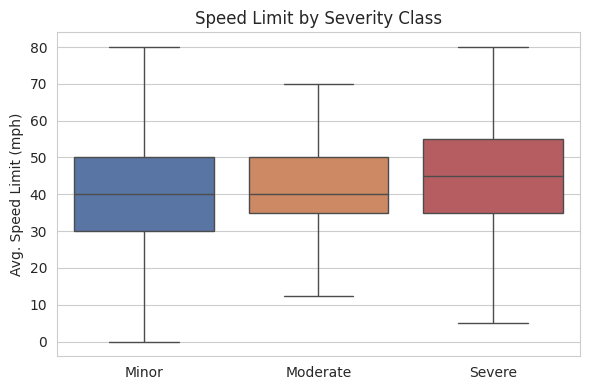

TARGET
Minor       40.9
Moderate    41.5
Severe      47.3
Name: avg_speed_limit, dtype: float64


In [24]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=final_df, x="TARGET", y="avg_speed_limit", hue="TARGET",
            order=SEVERITY_ORDER, palette=PALETTE, legend=False, ax=ax, showfliers=False)
ax.set_title("Speed Limit by Severity Class")
ax.set_xlabel("")
ax.set_ylabel("Avg. Speed Limit (mph)")
plt.tight_layout()
plt.show()

print(final_df.groupby("TARGET", observed=True)["avg_speed_limit"].mean().round(1))

Higher speed limits skew toward Severe — consistent with crash physics (kinetic energy scales with the square of speed), and a sanity check that the pipeline is capturing something real.

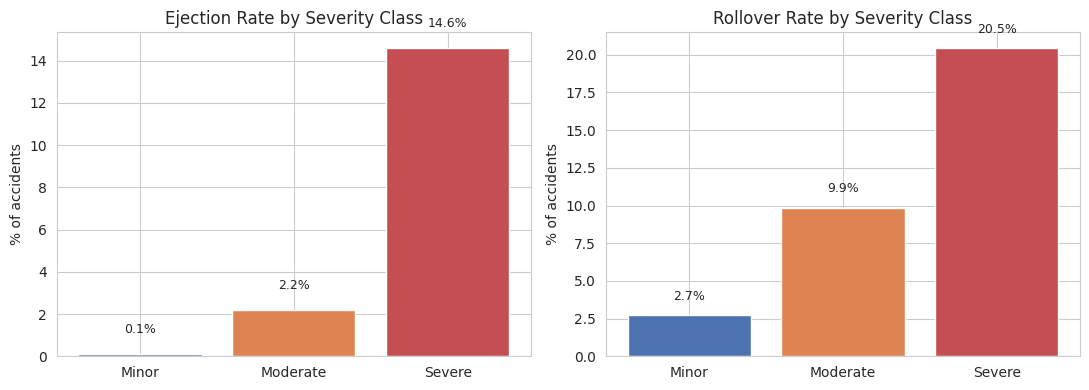

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col, title in [
    (axes[0], "ejection_flag", "Ejection Rate by Severity Class"),
    (axes[1], "rollover_flag", "Rollover Rate by Severity Class"),
]:
    rate = final_df.groupby("TARGET", observed=True)[col].mean().reindex(SEVERITY_ORDER)
    bars = ax.bar(SEVERITY_ORDER, rate.values * 100, color=[PALETTE[c] for c in SEVERITY_ORDER])
    for b, v in zip(bars, rate.values):
        ax.text(b.get_x() + b.get_width() / 2, v * 100 + 1, f"{v*100:.1f}%", ha="center", fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("% of accidents")

plt.tight_layout()
plt.show()

Both ejection and rollover show a clean monotonic step up from Minor to Severe — these are two of the strongest, most physically-grounded predictors in the dataset (an occupant ejection or vehicle rollover is a strong indicator of high-energy impact).

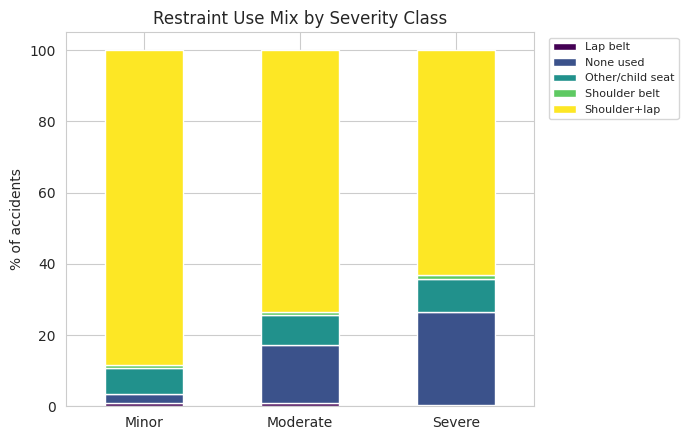

In [26]:
rest_map = {1: "Shoulder belt", 2: "Lap belt", 3: "Shoulder+lap", 20: "None used"}
final_df["restraint_group"] = final_df["restraint_mode"].map(rest_map).fillna("Other/child seat")

ct = pd.crosstab(final_df["TARGET"], final_df["restraint_group"], normalize="index") * 100
ct = ct.reindex(SEVERITY_ORDER)

fig, ax = plt.subplots(figsize=(7, 4.5))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Restraint Use Mix by Severity Class")
ax.set_ylabel("% of accidents")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

"None used" grows as a share of restraint types moving from Minor to Severe — restraint use is doing real work here, not just noise from the mode aggregation.

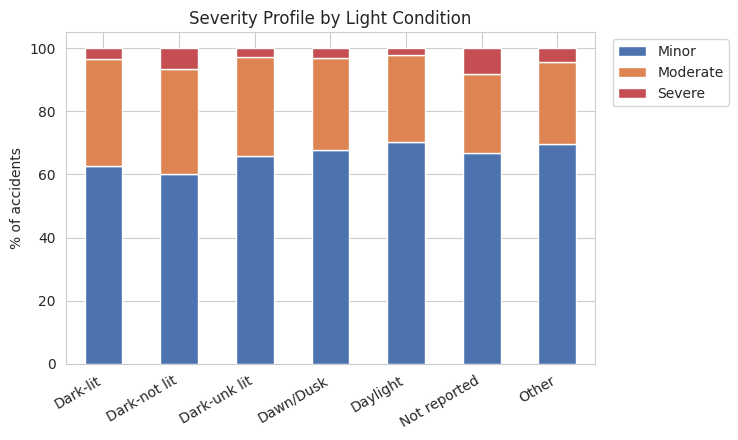

In [27]:
lc_map = {1: "Daylight", 2: "Dark-not lit", 3: "Dark-lit", 4: "Dawn/Dusk", 5: "Dark-unk lit", 6: "Other", 7: "Not reported"}
final_df["light_group"] = final_df["LGTCON_IM"].map(lc_map).fillna("Other")

ct2 = pd.crosstab(final_df["light_group"], final_df["TARGET"], normalize="index") * 100
ct2 = ct2[SEVERITY_ORDER]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ct2.plot(kind="bar", stacked=True, ax=ax, color=[PALETTE[c] for c in SEVERITY_ORDER])
ax.set_title("Severity Profile by Light Condition")
ax.set_ylabel("% of accidents")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Dark-not-lit conditions show a visibly higher Severe share than daylight — a smaller effect than speed or ejection, but consistent with reduced visibility and reaction time.

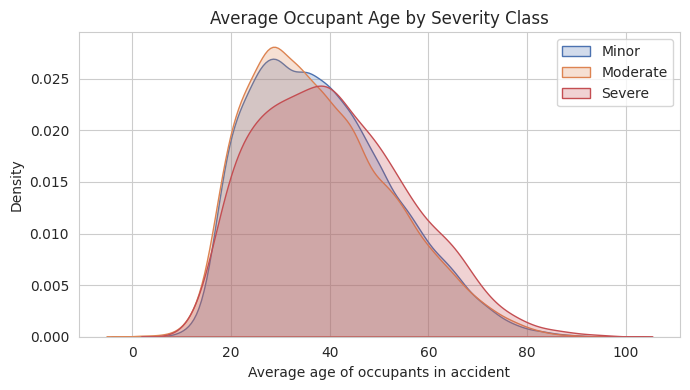

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))
for c in SEVERITY_ORDER:
    sub = final_df.loc[final_df["TARGET"] == c, "avg_age"].dropna()
    sns.kdeplot(sub, ax=ax, label=c, color=PALETTE[c], fill=True, alpha=0.25)
ax.set_title("Average Occupant Age by Severity Class")
ax.set_xlabel("Average age of occupants in accident")
ax.legend()
plt.tight_layout()
plt.show()

Age distributions largely overlap across classes — a much weaker signal than speed, ejection, or restraint use. Included specifically *because* it's a null-ish result: it's useful to know age isn't doing much work here rather than assume it and build features around it.

## 8. Missing-data indicators + final feature set

In [29]:
final_df["vehicle_data_missing"] = final_df["vehicle_count"].isna().astype(int)
final_df["speed_data_missing"] = final_df["avg_speed_limit"].isna().astype(int)

print("Vehicle data missing:")
print(final_df["vehicle_data_missing"].value_counts())
print("\nSpeed data missing:")
print(final_df["speed_data_missing"].value_counts())

Vehicle data missing:
vehicle_data_missing
0    53709
Name: count, dtype: int64

Speed data missing:
speed_data_missing
0    46757
1     6952
Name: count, dtype: int64


In [30]:
# Re-initialize X and y with all previous transformations applied
# Start from X_model after dropping hospital_mode
X = X_model.copy()
y = final_df["TARGET"].copy()

# Apply crash_p3_mode transformation
X["had_p3_phase"] = X["crash_p3_mode"].notna().astype(int)
X = X.drop(columns=["crash_p3_mode"])

# Apply VE_FORMS and vehicle_alcohol_flag drops
X = X.drop(columns=["VE_FORMS", "vehicle_alcohol_flag"])

# Adding the new missing data indicators to X
if "vehicle_data_missing" in final_df.columns:
    X["vehicle_data_missing"] = final_df["vehicle_data_missing"]
if "speed_data_missing" in final_df.columns:
    X["speed_data_missing"] = final_df["speed_data_missing"]

print("X shape after re-definition:", X.shape)
print("y shape after re-definition:", y.shape)

X shape after re-definition: (53709, 52)
y shape after re-definition: (53709,)


In [31]:
print(X.shape)
print("VE_FORMS" in X.columns)
print("vehicle_alcohol_flag" in X.columns)
print("crash_p3_mode" in X.columns)
print("had_p3_phase" in X.columns)

(53709, 52)
False
False
False
True


In [32]:
#fixing the duplicates found - judy
model_data = X.copy()
model_data["TARGET"] = y.values

print("Duplicate rows before:", model_data.duplicated().sum())

model_data = model_data.drop_duplicates().copy()

print("Duplicate rows after:", model_data.duplicated().sum())
print("Final modeling rows:", len(model_data))

X = model_data.drop(columns="TARGET")
y = model_data["TARGET"]

Duplicate rows before: 0
Duplicate rows after: 0
Final modeling rows: 53709


Judy did splitting

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (42967, 52)
X_test: (10742, 52)
y_train: (42967,)
y_test: (10742,)


## Summary — what's left for Part 2 (modeling)

- **Class imbalance** (Minor 68% / Moderate 29% / Severe 3%) needs `class_weight="balanced"` (or similar) and macro-F1/recall as the primary metric — accuracy alone will hide how the model does on Severe, which is the class that actually matters most.
- Strongest features going in: ejection, rollover, speed limit, restraint use, vehicle deformation/towing.
- `crash_p3_mode` is missing on ~66% of accidents (most crashes don't have a third pre-crash phase recorded) — worth deciding whether to keep, drop, or fold into a simpler "had 3rd phase" flag before modeling.

**Imputation**
for the missing values - Judy

In [34]:
continuous_cols = [
    "avg_occupants", "max_occupants", "avg_vehicle_age",
    "max_speed_limit", "avg_speed_limit",
    "avg_age", "min_age", "max_age",
    "person_count", "male_count", "female_count",
]
categorical_cols = [c for c in X_train.columns if c not in continuous_cols]

from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

X_train_imputed[continuous_cols] = num_imputer.fit_transform(X_train[continuous_cols])
X_test_imputed[continuous_cols] = num_imputer.transform(X_test[continuous_cols])

X_train_imputed[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test_imputed[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# **SMOTE**

In [35]:
from imblearn.over_sampling import SMOTENC

categorical_idx = [X_train_imputed.columns.get_loc(c) for c in categorical_cols]

smote = SMOTENC(categorical_features=categorical_idx, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
TARGET
Minor       29076
Moderate    12648
Severe       1243
Name: count, dtype: int64

After SMOTE:
TARGET
Minor       29076
Moderate    29076
Severe      29076
Name: count, dtype: int64


Judy checking for duplicates

In [36]:
print("Duplicate rows in X:", X.duplicated().sum())
print("Duplicate CASENUMs in final dataset:",
      final_df["CASENUM"].duplicated().sum())

Duplicate rows in X: 0
Duplicate CASENUMs in final dataset: 0


Outliers - Judy

In [37]:
numeric_summary = X.describe().T

print(numeric_summary[["min", "25%", "50%", "75%", "max"]])

                      min        25%    50%   75%    max
URBANICITY            1.0   1.000000   1.00   2.0    2.0
VE_TOTAL              1.0   1.000000   2.00   2.0   15.0
PVH_INVL              0.0   0.000000   0.00   0.0    6.0
PEDS                  0.0   0.000000   0.00   0.0    4.0
PERMVIT               0.0   1.000000   2.00   3.0   24.0
PERNOTMVIT            0.0   0.000000   0.00   0.0    6.0
MONTH                 1.0   5.000000   8.00  10.0   12.0
TYP_INT               1.0   1.000000   1.00   2.0   11.0
WRK_ZONE              0.0   0.000000   0.00   0.0    4.0
REL_ROAD              1.0   1.000000   1.00   1.0   12.0
SCH_BUS               0.0   0.000000   0.00   0.0    1.0
INT_HWY               0.0   0.000000   0.00   0.0    9.0
WKDY_IM               1.0   2.000000   4.00   6.0    7.0
HOUR_IM               0.0  10.000000  14.00  18.0   23.0
MINUTE_IM             0.0  13.000000  29.00  44.0   59.0
EVENT1_IM             1.0  12.000000  12.00  12.0   93.0
MANCOL_IM             0.0   0.0

In [38]:
continuous_cols = [
    "avg_occupants",
    "max_occupants",
    "avg_vehicle_age",
    "max_speed_limit",
    "avg_speed_limit",
    "avg_age",
    "min_age",
    "max_age",
    "person_count",
    "male_count",
    "female_count"
]

# Calculate IQR-based potential outliers
outlier_summary = []

for col in continuous_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X[col] < lower) | (X[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Potential Outliers": outliers,
        "Percentage": round(outliers / len(X) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

print(outlier_summary)

            Feature  Lower Bound  Upper Bound  Potential Outliers  Percentage
0     avg_occupants     0.250000         2.25                3785        7.05
1     max_occupants    -0.500000         3.50                2415        4.50
2   avg_vehicle_age    -7.166667        23.50                 712        1.33
3   max_speed_limit    12.500000        72.50                1143        2.13
4   avg_speed_limit    12.500000        72.50                1188        2.21
5           avg_age    -4.500000        79.50                 233        0.43
6           min_age   -11.000000        69.00                 921        1.71
7           max_age    -9.000000       103.00                   0        0.00
8      person_count     0.500000         4.50                3936        7.33
9        male_count    -0.500000         3.50                1550        2.89
10     female_count    -3.000000         5.00                 160        0.30


In [39]:
print(
    X.loc[X["avg_vehicle_age"] > 24.5, "avg_vehicle_age"]
    .sort_values(ascending=False)
    .head(20)
)
print(
    X.loc[X["avg_occupants"] > 2.25, "avg_occupants"]
    .sort_values(ascending=False)
    .head(20)
)

print(
    X.loc[X["max_occupants"] > 3.5, "max_occupants"]
    .sort_values(ascending=False)
    .head(20)
)

30660    88.0
23645    65.0
12626    59.0
15198    55.0
45231    55.0
9715     53.0
19210    52.0
17201    52.0
33458    50.0
5780     50.0
12367    50.0
17022    49.0
4570     47.0
38042    46.5
47310    46.0
24150    46.0
33862    45.0
7021     45.0
39753    43.0
7933     43.0
Name: avg_vehicle_age, dtype: float64
8125     25.5
42758    23.0
41998    23.0
8009     19.0
32867    18.0
31884    13.0
30204    12.5
31179    12.0
53677    11.5
4777     11.0
27572    11.0
15877    10.5
6344     10.0
28106    10.0
24045    10.0
26561     9.0
47946     9.0
45450     9.0
29864     8.0
12371     8.0
Name: avg_occupants, dtype: float64
8125     48.0
24045    24.0
30204    24.0
41998    23.0
42758    23.0
53677    22.0
31179    21.0
15877    20.0
8009     19.0
28106    19.0
6344     18.0
32867    18.0
47946    15.0
31884    13.0
38300    13.0
4777     11.0
27572    11.0
31750    11.0
2677     10.0
14697    10.0
Name: max_occupants, dtype: float64


Nothing to drop.

In [40]:
# Checking categorical data
print(X.dtypes)

URBANICITY                int64
VE_TOTAL                  int64
PVH_INVL                  int64
PEDS                      int64
PERMVIT                   int64
PERNOTMVIT                int64
MONTH                     int64
TYP_INT                 float64
WRK_ZONE                  int64
REL_ROAD                float64
SCH_BUS                   int64
INT_HWY                   int64
WKDY_IM                   int64
HOUR_IM                   int64
MINUTE_IM                 int64
EVENT1_IM                 int64
MANCOL_IM                 int64
RELJCT1_IM                int64
RELJCT2_IM                int64
LGTCON_IM                 int64
WEATHR_IM                 int64
ALCHL_IM                  int64
vehicle_count             int64
avg_occupants           float64
max_occupants           float64
hit_run_flag              int64
rollover_flag             int64
towed_flag                int64
avg_vehicle_age         float64
max_speed_limit         float64
avg_speed_limit         float64
max_defo

In [41]:
print(X.columns.tolist())

['URBANICITY', 'VE_TOTAL', 'PVH_INVL', 'PEDS', 'PERMVIT', 'PERNOTMVIT', 'MONTH', 'TYP_INT', 'WRK_ZONE', 'REL_ROAD', 'SCH_BUS', 'INT_HWY', 'WKDY_IM', 'HOUR_IM', 'MINUTE_IM', 'EVENT1_IM', 'MANCOL_IM', 'RELJCT1_IM', 'RELJCT2_IM', 'LGTCON_IM', 'WEATHR_IM', 'ALCHL_IM', 'vehicle_count', 'avg_occupants', 'max_occupants', 'hit_run_flag', 'rollover_flag', 'towed_flag', 'avg_vehicle_age', 'max_speed_limit', 'avg_speed_limit', 'max_deformation', 'impact_mode', 'crash_p1_mode', 'crash_p2_mode', 'person_count', 'avg_age', 'min_age', 'max_age', 'male_count', 'female_count', 'seat_position_mode', 'restraint_mode', 'helmet_mode', 'ejection_flag', 'drinking_flag', 'alcohol_status_mode', 'drugs_flag', 'location_mode', 'had_p3_phase', 'vehicle_data_missing', 'speed_data_missing']


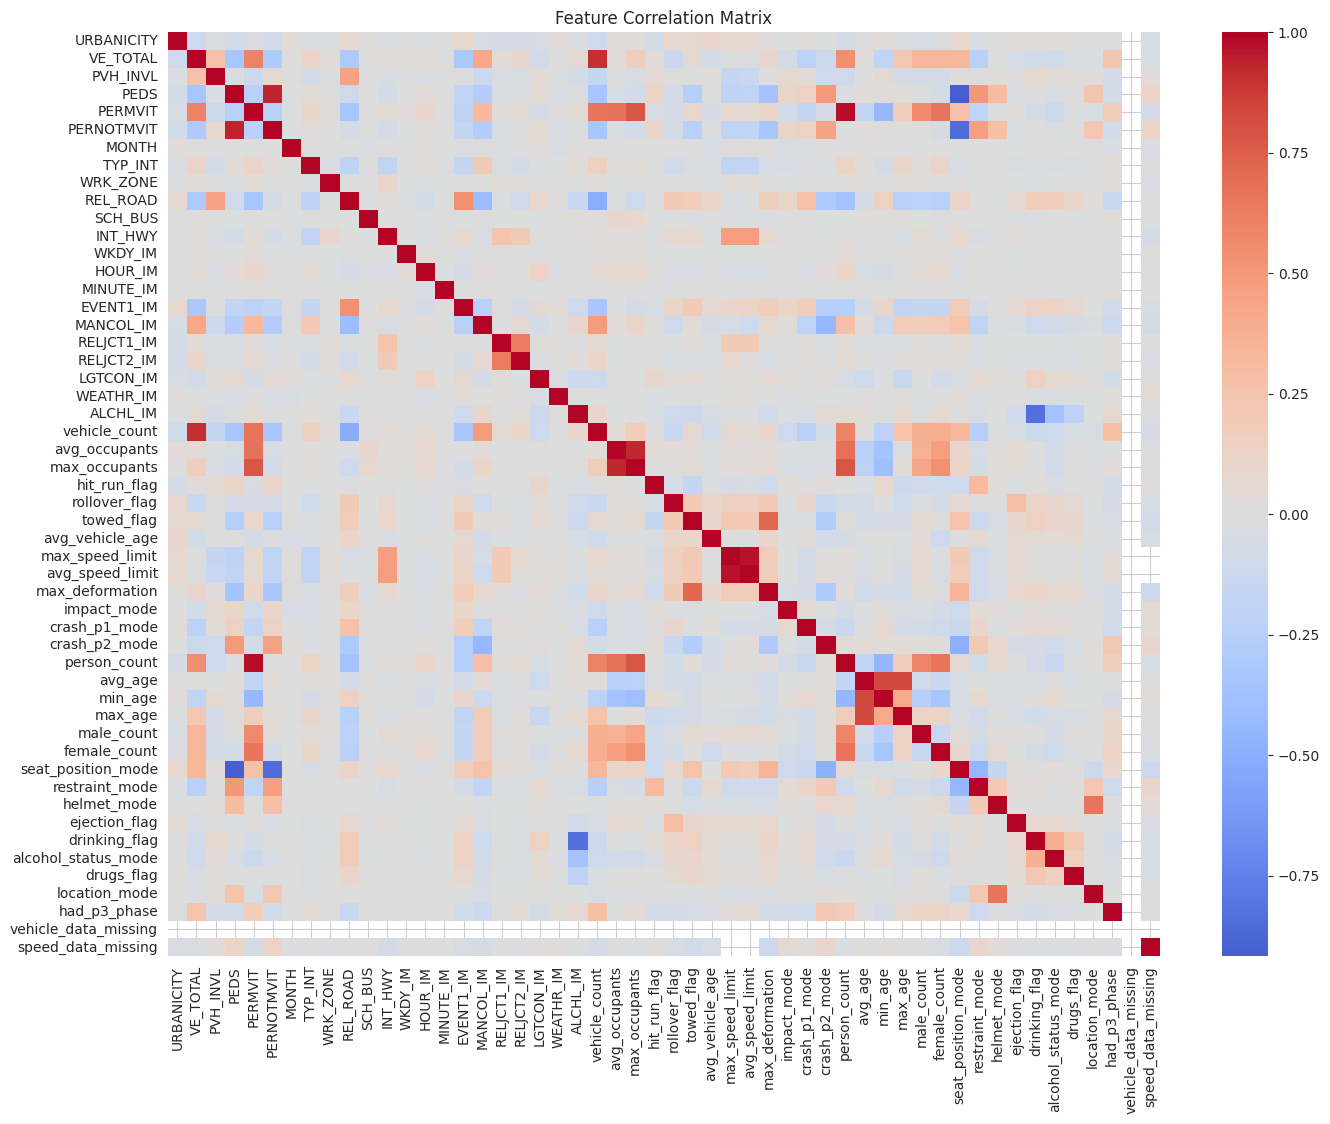

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
corr = X.corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [43]:
corr = X.corr().abs()

# Keep only the upper triangle so we don't see each pair twice
upper = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)
high_corr = (
    upper.stack()
    .reset_index()
)

high_corr.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = high_corr.sort_values(
    "Correlation",
    ascending=False
)

print(high_corr[high_corr["Correlation"] >= 0.80].to_string(index=False))

      Feature 1          Feature 2  Correlation
        PERMVIT       person_count     0.970635
max_speed_limit    avg_speed_limit     0.968993
           PEDS         PERNOTMVIT     0.933542
  avg_occupants      max_occupants     0.925693
           PEDS seat_position_mode     0.916782
       VE_TOTAL      vehicle_count     0.904562
     PERNOTMVIT seat_position_mode     0.850475
       ALCHL_IM      drinking_flag     0.835373
        avg_age            max_age     0.833481
        avg_age            min_age     0.831538


In [44]:
print("VE_FORMS was removed from X.")
# print((X["VE_FORMS"] == X["vehicle_count"]).all())

VE_FORMS was removed from X.


In [45]:
print("VE_FORMS was removed from X, skipping equality check.")
# print("VE_FORMS == vehicle_count:",
#       (X["VE_FORMS"] == X["vehicle_count"]).all())

# print("Number of differences:",
#       (X["VE_FORMS"] != X["vehicle_count"]).sum())

VE_FORMS was removed from X, skipping equality check.


In [46]:
print("VE_FORMS was removed from X, skipping its removal.")
# X = X.drop(columns=["VE_FORMS"])
print("VE_FORMS" in X.columns)
print(X.shape)

VE_FORMS was removed from X, skipping its removal.
False
(53709, 52)


In [47]:
print("PERMVIT == person_count:",
      (X["PERMVIT"] == X["person_count"]).all())

print("Number of differences:",
      (X["PERMVIT"] != X["person_count"]).sum())

print(X[["PERMVIT", "person_count"]].describe())

PERMVIT == person_count: False
Number of differences: 5200
            PERMVIT  person_count
count  53709.000000  53709.000000
mean       2.331732      2.434173
std        1.359029      1.317301
min        0.000000      1.000000
25%        1.000000      2.000000
50%        2.000000      2.000000
75%        3.000000      3.000000
max       24.000000     24.000000


In [48]:
print("Exactly equal:",
      (X["max_speed_limit"] == X["avg_speed_limit"]).all())

print("Number of differences:",
      (X["max_speed_limit"] != X["avg_speed_limit"]).sum())

print(X[["max_speed_limit", "avg_speed_limit"]].describe())

Exactly equal: False
Number of differences: 10486
       max_speed_limit  avg_speed_limit
count     46757.000000     46757.000000
mean         42.152405        41.305225
std          13.987625        14.491179
min           0.000000         0.000000
25%          35.000000        35.000000
50%          40.000000        40.000000
75%          50.000000        50.000000
max          90.000000        90.000000


In [49]:
pairs = [
    # ("vehicle_alcohol_flag", "drinking_flag"), # Removed as vehicle_alcohol_flag is no longer in X
    ("PEDS", "PERNOTMVIT"),
    ("avg_occupants", "max_occupants"),
    ("avg_age", "max_age"),
    ("avg_age", "min_age"),
]

for col1, col2 in pairs:

    print("\n" + "=" * 70)
    print(f"{col1}  vs  {col2}")
    print("=" * 70)

    # Correlation
    print(f"Correlation: {X[col1].corr(X[col2]):.4f}")

    print(f"Exactly equal: {(X[col1] == X[col2]).all()}")

    print(f"Number of differences: {(X[col1] != X[col2]).sum()}")

    print("\nSummary:")
    print(X[[col1, col2]].describe())

    print("\nFirst 10 observations:")
    print(X[[col1, col2]].head(10))

print("\n" + "=" * 70)
print("ALCOHOL FLAG CROSS-TABULATION")
print("=" * 70)

# Commented out as 'vehicle_alcohol_flag' is no longer in X
# print(pd.crosstab(
#     X["vehicle_alcohol_flag"],
#     X["drinking_flag"],
#     margins=True
# ))


PEDS  vs  PERNOTMVIT
Correlation: 0.9335
Exactly equal: False
Number of differences: 322

Summary:
               PEDS    PERNOTMVIT
count  53709.000000  53709.000000
mean       0.094528      0.102441
std        0.305332      0.326927
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max        4.000000      6.000000

First 10 observations:
   PEDS  PERNOTMVIT
0     0           0
1     0           0
2     0           0
3     0           0
4     0           0
5     0           0
6     0           0
7     0           0
8     0           0
9     0           0

avg_occupants  vs  max_occupants
Correlation: 0.9257
Exactly equal: False
Number of differences: 14886

Summary:
       avg_occupants  max_occupants
count   51920.000000   51920.000000
mean        1.353392       1.548247
std         0.674459       0.975293
min         0.000000       0.000000
25%         1.000000       1.000000
50%         1.000000

In [50]:
pairs = [
    # ("vehicle_alcohol_flag", "drinking_flag"), # Removed as vehicle_alcohol_flag is no longer in X
    ("PEDS", "PERNOTMVIT"),
    ("avg_occupants", "max_occupants"),
    ("avg_age", "max_age"),
    ("avg_age", "min_age"),
]

for col1, col2 in pairs:

    print("\n" + "=" * 70)
    print(f"{col1}  vs  {col2}")
    print("=" * 70)

    # Correlation
    print(f"Correlation: {X[col1].corr(X[col2]):.4f}")

    print(f"Exactly equal: {(X[col1] == X[col2]).all()}")

    print(f"Number of differences: {(X[col1] != X[col2]).sum()}")

    print("\nSummary:")
    print(X[[col1, col2]].describe())

    print("\nFirst 10 observations:")
    print(X[[col1, col2]].head(10))

print("\n" + "=" * 70)
print("ALCOHOL FLAG CROSS-TABULATION")
print("=" * 70)

# Commented out as 'vehicle_alcohol_flag' is no longer in X
# print(pd.crosstab(
#     X["vehicle_alcohol_flag"],
#     X["drinking_flag"],
#     margins=True
# ))


PEDS  vs  PERNOTMVIT
Correlation: 0.9335
Exactly equal: False
Number of differences: 322

Summary:
               PEDS    PERNOTMVIT
count  53709.000000  53709.000000
mean       0.094528      0.102441
std        0.305332      0.326927
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max        4.000000      6.000000

First 10 observations:
   PEDS  PERNOTMVIT
0     0           0
1     0           0
2     0           0
3     0           0
4     0           0
5     0           0
6     0           0
7     0           0
8     0           0
9     0           0

avg_occupants  vs  max_occupants
Correlation: 0.9257
Exactly equal: False
Number of differences: 14886

Summary:
       avg_occupants  max_occupants
count   51920.000000   51920.000000
mean        1.353392       1.548247
std         0.674459       0.975293
min         0.000000       0.000000
25%         1.000000       1.000000
50%         1.000000

In [51]:
pairs = [
    # ("vehicle_alcohol_flag", "drinking_flag"), # Removed as vehicle_alcohol_flag is no longer in X
    ("PEDS", "PERNOTMVIT"),
    ("avg_occupants", "max_occupants"),
    ("avg_age", "max_age"),
    ("avg_age", "min_age"),
]

for col1, col2 in pairs:

    print("\n" + "=" * 70)
    print(f"{col1}  vs  {col2}")
    print("=" * 70)

    # Correlation
    print(f"Correlation: {X[col1].corr(X[col2]):.4f}")

    print(f"Exactly equal: {(X[col1] == X[col2]).all()}")

    print(f"Number of differences: {(X[col1] != X[col2]).sum()}")

    print("\nSummary:")
    print(X[[col1, col2]].describe())

    print("\nFirst 10 observations:")
    print(X[[col1, col2]].head(10))

print("\n" + "=" * 70)
print("ALCOHOL FLAG CROSS-TABULATION")
print("=" * 70)

# Commented out as 'vehicle_alcohol_flag' is no longer in X
# print(pd.crosstab(
#     X["vehicle_alcohol_flag"],
#     X["drinking_flag"],
#     margins=True
# ))


PEDS  vs  PERNOTMVIT
Correlation: 0.9335
Exactly equal: False
Number of differences: 322

Summary:
               PEDS    PERNOTMVIT
count  53709.000000  53709.000000
mean       0.094528      0.102441
std        0.305332      0.326927
min        0.000000      0.000000
25%        0.000000      0.000000
50%        0.000000      0.000000
75%        0.000000      0.000000
max        4.000000      6.000000

First 10 observations:
   PEDS  PERNOTMVIT
0     0           0
1     0           0
2     0           0
3     0           0
4     0           0
5     0           0
6     0           0
7     0           0
8     0           0
9     0           0

avg_occupants  vs  max_occupants
Correlation: 0.9257
Exactly equal: False
Number of differences: 14886

Summary:
       avg_occupants  max_occupants
count   51920.000000   51920.000000
mean        1.353392       1.548247
std         0.674459       0.975293
min         0.000000       0.000000
25%         1.000000       1.000000
50%         1.000000

In [52]:
# X = X.drop(columns=["vehicle_alcohol_flag"]) # Commented out as 'vehicle_alcohol_flag' is no longer in X

print("vehicle_alcohol_flag" in X.columns)

False


In [53]:
# X = X.drop(columns=["vehicle_alcohol_flag"]) # Commented out as 'vehicle_alcohol_flag' is no longer in X

print("vehicle_alcohol_flag" in X.columns)

False


In [54]:
# X = X.drop(columns=["vehicle_alcohol_flag"]) # Commented out as 'vehicle_alcohol_flag' is no longer in X

print("vehicle_alcohol_flag" in X.columns)

False


In [55]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest for feature-importance screening
rf_screen = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_screen.fit(X_train_imputed, y_train)

# Get feature importance
importance = pd.DataFrame({
    "Feature": X_train_imputed.columns,
    "Importance": rf_screen.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.to_string(index=False))

             Feature  Importance
             max_age    0.053009
          towed_flag    0.052581
             avg_age    0.052489
           MINUTE_IM    0.050804
     avg_vehicle_age    0.050623
             min_age    0.048727
             HOUR_IM    0.045366
       crash_p2_mode    0.043071
               MONTH    0.038298
     avg_speed_limit    0.033171
         impact_mode    0.032795
     max_speed_limit    0.031988
           EVENT1_IM    0.030968
             WKDY_IM    0.030704
     max_deformation    0.029198
      restraint_mode    0.028706
         helmet_mode    0.023077
          male_count    0.018411
           MANCOL_IM    0.018019
       ejection_flag    0.017762
          RELJCT2_IM    0.017452
           LGTCON_IM    0.017442
        female_count    0.015915
       crash_p1_mode    0.014670
           WEATHR_IM    0.013058
        person_count    0.012961
             PERMVIT    0.012400
             TYP_INT    0.012029
 alcohol_status_mode    0.011810
          

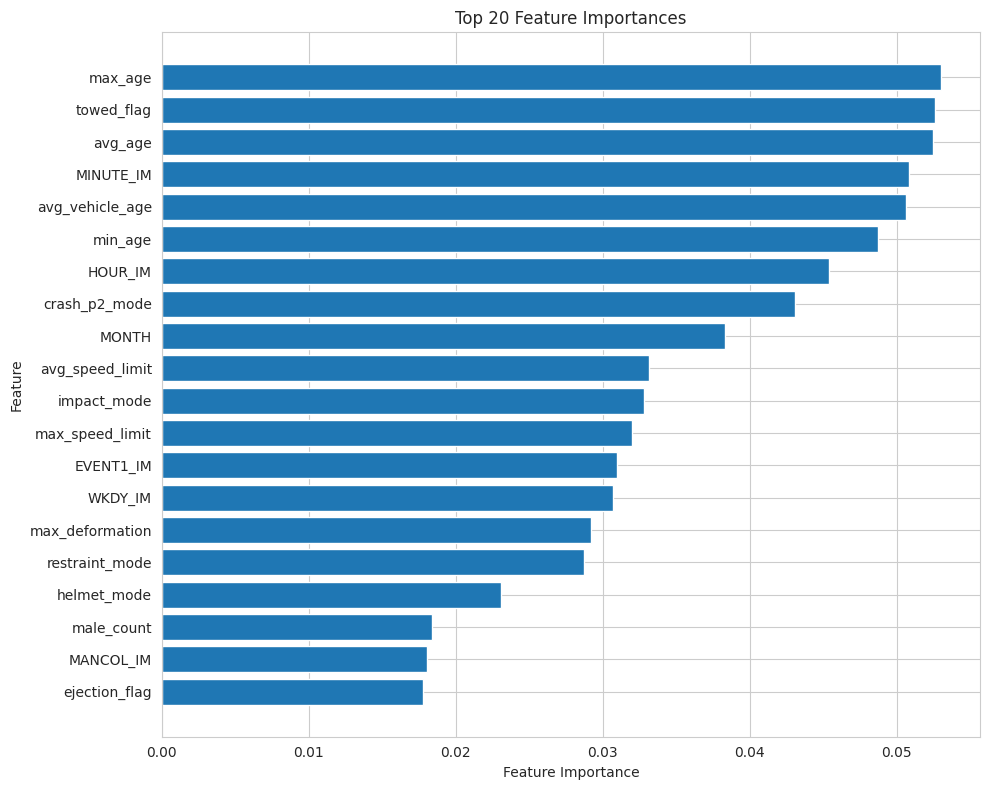

In [56]:
top_n = 20

plt.figure(figsize=(10, 8))

plt.barh(
    importance["Feature"].head(top_n)[::-1],
    importance["Importance"].head(top_n)[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.show()

In [57]:
print("crash_p3_mode exists:", "crash_p3_mode" in X.columns)

if "crash_p3_mode" in X.columns:
    print("\nUnique values:")
    print(sorted(X["crash_p3_mode"].dropna().unique()))

    print("\nValue counts:")
    print(X["crash_p3_mode"].value_counts().sort_index())

crash_p3_mode exists: False


In [58]:
print([col for col in X.columns if "P3" in col.upper() or "P3" in col.upper()])
print(X.columns.tolist())

['had_p3_phase']
['URBANICITY', 'VE_TOTAL', 'PVH_INVL', 'PEDS', 'PERMVIT', 'PERNOTMVIT', 'MONTH', 'TYP_INT', 'WRK_ZONE', 'REL_ROAD', 'SCH_BUS', 'INT_HWY', 'WKDY_IM', 'HOUR_IM', 'MINUTE_IM', 'EVENT1_IM', 'MANCOL_IM', 'RELJCT1_IM', 'RELJCT2_IM', 'LGTCON_IM', 'WEATHR_IM', 'ALCHL_IM', 'vehicle_count', 'avg_occupants', 'max_occupants', 'hit_run_flag', 'rollover_flag', 'towed_flag', 'avg_vehicle_age', 'max_speed_limit', 'avg_speed_limit', 'max_deformation', 'impact_mode', 'crash_p1_mode', 'crash_p2_mode', 'person_count', 'avg_age', 'min_age', 'max_age', 'male_count', 'female_count', 'seat_position_mode', 'restraint_mode', 'helmet_mode', 'ejection_flag', 'drinking_flag', 'alcohol_status_mode', 'drugs_flag', 'location_mode', 'had_p3_phase', 'vehicle_data_missing', 'speed_data_missing']


In [59]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget in X:", "TARGET" in X.columns)

print("\nP3 feature:")
print(X["had_p3_phase"].value_counts(dropna=False))

X shape: (53709, 52)
y shape: (53709,)

Target in X: False

P3 feature:
had_p3_phase
0    35588
1    18121
Name: count, dtype: int64


In [60]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nSMOTE:")
print("X_train_smote:", X_train_smote.shape)
print("y_train_smote:", y_train_smote.shape)

X_train: (42967, 52)
X_test: (10742, 52)
y_train: (42967,)
y_test: (10742,)

SMOTE:
X_train_smote: (87228, 52)
y_train_smote: (87228,)


In [61]:
print("X columns:", len(X.columns))
print("X_train columns:", len(X_train.columns))

print("\nColumns in X_train but not X:")
print([c for c in X_train.columns if c not in X.columns])

print("\nAll X_train columns:")
print(X_train.columns.tolist())

X columns: 52
X_train columns: 52

Columns in X_train but not X:
[]

All X_train columns:
['URBANICITY', 'VE_TOTAL', 'PVH_INVL', 'PEDS', 'PERMVIT', 'PERNOTMVIT', 'MONTH', 'TYP_INT', 'WRK_ZONE', 'REL_ROAD', 'SCH_BUS', 'INT_HWY', 'WKDY_IM', 'HOUR_IM', 'MINUTE_IM', 'EVENT1_IM', 'MANCOL_IM', 'RELJCT1_IM', 'RELJCT2_IM', 'LGTCON_IM', 'WEATHR_IM', 'ALCHL_IM', 'vehicle_count', 'avg_occupants', 'max_occupants', 'hit_run_flag', 'rollover_flag', 'towed_flag', 'avg_vehicle_age', 'max_speed_limit', 'avg_speed_limit', 'max_deformation', 'impact_mode', 'crash_p1_mode', 'crash_p2_mode', 'person_count', 'avg_age', 'min_age', 'max_age', 'male_count', 'female_count', 'seat_position_mode', 'restraint_mode', 'helmet_mode', 'ejection_flag', 'drinking_flag', 'alcohol_status_mode', 'drugs_flag', 'location_mode', 'had_p3_phase', 'vehicle_data_missing', 'speed_data_missing']


In [62]:
print([c for c in X_train.columns if c not in X.columns])

[]


In [63]:
FINAL_FEATURES = X.columns.tolist()

print(f"Number of final features: {len(FINAL_FEATURES)}")
print("\nFinal feature set:")
for i, feature in enumerate(FINAL_FEATURES, 1):
    print(f"{i:2}. {feature}")

Number of final features: 52

Final feature set:
 1. URBANICITY
 2. VE_TOTAL
 3. PVH_INVL
 4. PEDS
 5. PERMVIT
 6. PERNOTMVIT
 7. MONTH
 8. TYP_INT
 9. WRK_ZONE
10. REL_ROAD
11. SCH_BUS
12. INT_HWY
13. WKDY_IM
14. HOUR_IM
15. MINUTE_IM
16. EVENT1_IM
17. MANCOL_IM
18. RELJCT1_IM
19. RELJCT2_IM
20. LGTCON_IM
21. WEATHR_IM
22. ALCHL_IM
23. vehicle_count
24. avg_occupants
25. max_occupants
26. hit_run_flag
27. rollover_flag
28. towed_flag
29. avg_vehicle_age
30. max_speed_limit
31. avg_speed_limit
32. max_deformation
33. impact_mode
34. crash_p1_mode
35. crash_p2_mode
36. person_count
37. avg_age
38. min_age
39. max_age
40. male_count
41. female_count
42. seat_position_mode
43. restraint_mode
44. helmet_mode
45. ejection_flag
46. drinking_flag
47. alcohol_status_mode
48. drugs_flag
49. location_mode
50. had_p3_phase
51. vehicle_data_missing
52. speed_data_missing


In [64]:
assert "TARGET" not in X.columns
assert "crash_p3_mode" not in X.columns
assert "hospital_mode" not in X.columns
assert "VE_FORMS" not in X.columns
assert "vehicle_alcohol_flag" not in X.columns
assert "had_p3_phase" in X.columns

print("✅ Feature set frozen successfully.")

✅ Feature set frozen successfully.


# 1.Random Forest

In [67]:
# ============================================
# Random Forest Classifier
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train the model on the balanced training data
rf_model.fit(X_train_smote, y_train_smote)

# Predict on the ORIGINAL untouched test set
y_pred_rf = rf_model.predict(X_test_imputed)

# ============================================
# Evaluation
# ============================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average="macro", zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, average="macro", zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average="macro", zero_division=0)

print("Random Forest Results")
print("=" * 50)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"Macro F1 : {f1_rf:.4f}")

print("\nClassification Report")
print("=" * 50)
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

Random Forest Results
Accuracy : 0.7326
Precision: 0.5758
Recall   : 0.5264
Macro F1 : 0.5390

Classification Report
              precision    recall  f1-score   support

       Minor       0.83      0.81      0.82      7269
    Moderate       0.56      0.61      0.58      3162
      Severe       0.35      0.16      0.22       311

    accuracy                           0.73     10742
   macro avg       0.58      0.53      0.54     10742
weighted avg       0.73      0.73      0.73     10742



Confusion Matrix:
[[5886 1350   33]
 [1167 1935   60]
 [  61  201   49]]


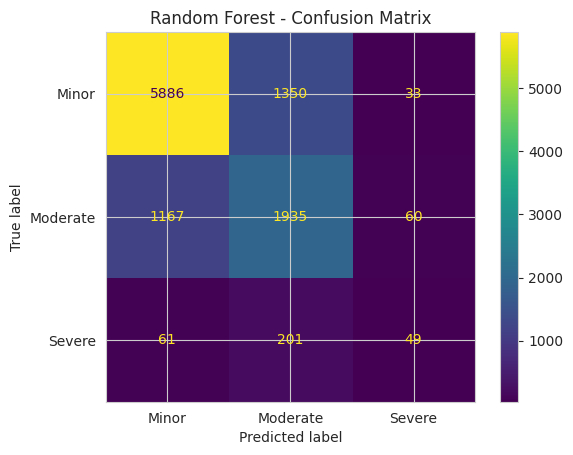

In [68]:
# ============================================
# Random Forest - Confusion Matrix
# ============================================

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Catboost

In [70]:
!pip install catboost
import catboost
print(catboost.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.8 MB/s eta 0:00:00
1.2.10


In [71]:
# ============================================
# CatBoost Classifier
# ============================================

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Create the CatBoost model
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=100
)

# Train on the balanced training data
catboost_model.fit(
    X_train_smote,
    y_train_smote
)

# Predict on the untouched test set
y_pred_cat = catboost_model.predict(X_test_imputed)

# CatBoost returns predictions as a 2D array
y_pred_cat = y_pred_cat.ravel()

# ============================================
# Evaluation
# ============================================

accuracy_cat = accuracy_score(y_test, y_pred_cat)
precision_cat = precision_score(
    y_test,
    y_pred_cat,
    average="macro",
    zero_division=0
)
recall_cat = recall_score(
    y_test,
    y_pred_cat,
    average="macro",
    zero_division=0
)
f1_cat = f1_score(
    y_test,
    y_pred_cat,
    average="macro",
    zero_division=0
)

print("\nCatBoost Results")
print("=" * 50)
print(f"Accuracy : {accuracy_cat:.4f}")
print(f"Precision: {precision_cat:.4f}")
print(f"Recall   : {recall_cat:.4f}")
print(f"Macro F1 : {f1_cat:.4f}")

print("\nClassification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_cat,
    zero_division=0
))

0:	learn: 0.6354954	total: 316ms	remaining: 2m 37s
100:	learn: 0.7410157	total: 20.6s	remaining: 1m 21s
200:	learn: 0.7743617	total: 34.5s	remaining: 51.3s
300:	learn: 0.7990571	total: 42.6s	remaining: 28.2s
400:	learn: 0.8147900	total: 52.5s	remaining: 12.9s
499:	learn: 0.8252318	total: 1m 1s	remaining: 0us

CatBoost Results
Accuracy : 0.7272
Precision: 0.5525
Recall   : 0.5707
Macro F1 : 0.5606

Classification Report
              precision    recall  f1-score   support

       Minor       0.84      0.80      0.82      7269
    Moderate       0.56      0.60      0.58      3162
      Severe       0.27      0.31      0.29       311

    accuracy                           0.73     10742
   macro avg       0.55      0.57      0.56     10742
weighted avg       0.74      0.73      0.73     10742



Confusion Matrix:
[[5818 1352   99]
 [1097 1897  168]
 [  49  165   97]]


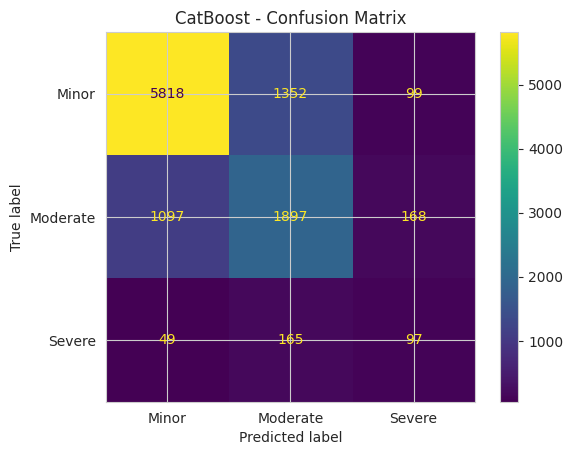

In [72]:
# ============================================
# CatBoost - Confusion Matrix
# ============================================

cm_cat = confusion_matrix(y_test, y_pred_cat)

print("Confusion Matrix:")
print(cm_cat)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cat,
    display_labels=catboost_model.classes_
)

disp.plot()
plt.title("CatBoost - Confusion Matrix")
plt.show()

# XGBoost

In [73]:
!pip install xgboost

In [74]:
import xgboost
print(xgboost.__version__)

3.3.0


In [76]:
# ============================================
# XGBoost Classifier
# ============================================

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# --------------------------------------------
# Encode target labels for XGBoost
# Minor    -> 0
# Moderate -> 1
# Severe   -> 2
# --------------------------------------------

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train_smote)
y_test_xgb = label_encoder.transform(y_test)

print("Class mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# --------------------------------------------
# Create XGBoost model
# --------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Train on balanced training data
xgb_model.fit(
    X_train_smote,
    y_train_xgb
)

# Predict on untouched test data
y_pred_xgb_encoded = xgb_model.predict(X_test_imputed)

# Convert predictions back to original class names
y_pred_xgb = label_encoder.inverse_transform(
    y_pred_xgb_encoded.astype(int)
)

# --------------------------------------------
# Evaluation
# --------------------------------------------

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

precision_xgb = precision_score(
    y_test,
    y_pred_xgb,
    average="macro",
    zero_division=0
)

recall_xgb = recall_score(
    y_test,
    y_pred_xgb,
    average="macro",
    zero_division=0
)

f1_xgb = f1_score(
    y_test,
    y_pred_xgb,
    average="macro",
    zero_division=0
)

print("\nXGBoost Results")
print("=" * 50)
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"Macro F1 : {f1_xgb:.4f}")

print("\nClassification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_xgb,
    zero_division=0
))

Class mapping:
Minor -> 0
Moderate -> 1
Severe -> 2

XGBoost Results
Accuracy : 0.7389
Precision: 0.5735
Recall   : 0.5561
Macro F1 : 0.5640

Classification Report
              precision    recall  f1-score   support

       Minor       0.82      0.84      0.83      7269
    Moderate       0.58      0.56      0.57      3162
      Severe       0.32      0.27      0.30       311

    accuracy                           0.74     10742
   macro avg       0.57      0.56      0.56     10742
weighted avg       0.73      0.74      0.74     10742



Confusion Matrix:
[[6090 1124   55]
 [1277 1762  123]
 [  60  166   85]]


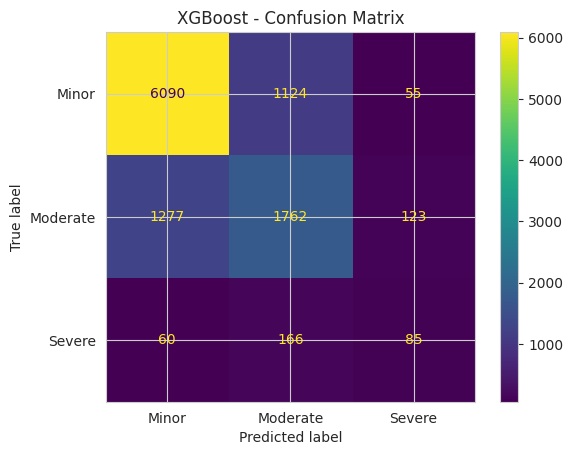

In [77]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

# Logistic Regression

In [78]:
# ============================================
# Logistic Regression - Preprocessing
# ============================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Separate numerical and categorical columns
numeric_features = [
    col for col in X_train_smote.columns
    if col not in categorical_cols
]

categorical_features = [
    col for col in categorical_cols
    if col in X_train_smote.columns
]

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True
    ))
])

# Combine preprocessing
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Logistic Regression preprocessing is ready.")

Number of numerical features: 11
Number of categorical features: 41
Logistic Regression preprocessing is ready.


In [79]:
# ============================================
# Logistic Regression - Training
# ============================================

# Create Logistic Regression model
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train on the balanced training data
lr_model.fit(
    X_train_smote,
    y_train_smote
)

# Predict on the untouched test data
y_pred_lr = lr_model.predict(X_test_imputed)

# ============================================
# Evaluation
# ============================================

accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="macro",
    zero_division=0
)

print("\nLogistic Regression Results")
print("=" * 50)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"Macro F1 : {f1_lr:.4f}")

print("\nClassification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_lr,
    zero_division=0
))


Logistic Regression Results
Accuracy : 0.6800
Precision: 0.5055
Recall   : 0.5822
Macro F1 : 0.5212

Classification Report
              precision    recall  f1-score   support

       Minor       0.85      0.74      0.79      7269
    Moderate       0.51      0.58      0.54      3162
      Severe       0.16      0.43      0.24       311

    accuracy                           0.68     10742
   macro avg       0.51      0.58      0.52     10742
weighted avg       0.73      0.68      0.70     10742



Confusion Matrix:
[[5345 1633  291]
 [ 933 1825  404]
 [  42  134  135]]


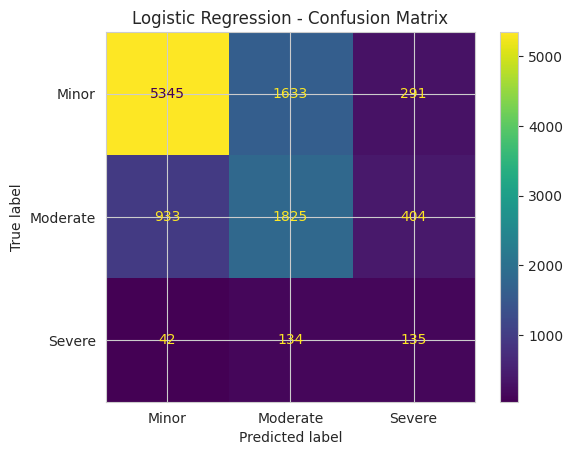

In [80]:
# ============================================
# Logistic Regression - Confusion Matrix
# ============================================

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_model.classes_
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Base-line comparison cell

In [81]:
# ============================================
# Baseline Model Comparison
# ============================================

model_results = {
    "Random Forest": {
        "Accuracy": accuracy_rf,
        "Macro Precision": precision_rf,
        "Macro Recall": recall_rf,
        "Macro F1": f1_rf,
        "Severe Recall": recall_score(
            y_test, y_pred_rf,
            labels=["Severe"],
            average="macro",
            zero_division=0
        ),
        "Severe F1": f1_score(
            y_test, y_pred_rf,
            labels=["Severe"],
            average="macro",
            zero_division=0
        )
    },

    "CatBoost": {
        "Accuracy": accuracy_cat,
        "Macro Precision": precision_cat,
        "Macro Recall": recall_cat,
        "Macro F1": f1_cat,
        "Severe Recall": recall_score(
            y_test, y_pred_cat,
            labels=["Severe"],
            average="macro",
            zero_division=0
        ),
        "Severe F1": f1_score(
            y_test, y_pred_cat,
            labels=["Severe"],
            average="macro",
            zero_division=0
        )
    },

    "XGBoost": {
        "Accuracy": accuracy_xgb,
        "Macro Precision": precision_xgb,
        "Macro Recall": recall_xgb,
        "Macro F1": f1_xgb,
        "Severe Recall": recall_score(
            y_test, y_pred_xgb,
            labels=["Severe"],
            average="macro",
            zero_division=0
        ),
        "Severe F1": f1_score(
            y_test, y_pred_xgb,
            labels=["Severe"],
            average="macro",
            zero_division=0
        )
    },

    "Logistic Regression": {
        "Accuracy": accuracy_lr,
        "Macro Precision": precision_lr,
        "Macro Recall": recall_lr,
        "Macro F1": f1_lr,
        "Severe Recall": recall_score(
            y_test, y_pred_lr,
            labels=["Severe"],
            average="macro",
            zero_division=0
        ),
        "Severe F1": f1_score(
            y_test, y_pred_lr,
            labels=["Severe"],
            average="macro",
            zero_division=0
        )
    }
}

results_df = pd.DataFrame(model_results).T

print("Baseline Model Comparison")
print("=" * 80)

display(
    results_df.round(4)
)

Baseline Model Comparison


,Accuracy,Macro Precision,Macro Recall,Macro F1,Severe Recall,Severe F1
Random Forest,0.7326,0.5758,0.5264,0.5390,0.1576,0.2163
CatBoost,0.7272,0.5525,0.5707,0.5606,0.3119,0.2874
XGBoost,0.7389,0.5735,0.5561,0.5640,0.2733,0.2962
Logistic Regression,0.6800,0.5055,0.5822,0.5212,0.4341,0.2366


# Weighted XGB-Boost

In [82]:
# ============================================
# Weighted XGBoost
# ============================================

from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# Encode the ORIGINAL training labels
# (we are NOT using the SMOTE training set here)
label_encoder_w = LabelEncoder()

y_train_original_encoded = label_encoder_w.fit_transform(y_train)
y_test_w = label_encoder_w.transform(y_test)

print("Class mapping:")
for i, class_name in enumerate(label_encoder_w.classes_):
    print(f"{class_name} -> {i}")

# Calculate a weight for every ORIGINAL training sample
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_original_encoded
)

print("\nSample weights created.")
print("Weight range:", sample_weights.min(), "to", sample_weights.max())

# ============================================
# Create weighted XGBoost
# ============================================

xgb_weighted = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Train on the ORIGINAL training data
# with class-based sample weights
xgb_weighted.fit(
    X_train_imputed,
    y_train_original_encoded,
    sample_weight=sample_weights
)

# Predict on the untouched test set
y_pred_xgb_weighted_encoded = xgb_weighted.predict(X_test_imputed)

# Convert predictions back to original class names
y_pred_xgb_weighted = label_encoder_w.inverse_transform(
    y_pred_xgb_weighted_encoded.astype(int)
)

# ============================================
# Evaluation
# ============================================

accuracy_xgb_weighted = accuracy_score(
    y_test,
    y_pred_xgb_weighted
)

precision_xgb_weighted = precision_score(
    y_test,
    y_pred_xgb_weighted,
    average="macro",
    zero_division=0
)

recall_xgb_weighted = recall_score(
    y_test,
    y_pred_xgb_weighted,
    average="macro",
    zero_division=0
)

f1_xgb_weighted = f1_score(
    y_test,
    y_pred_xgb_weighted,
    average="macro",
    zero_division=0
)

print("\nWeighted XGBoost Results")
print("=" * 50)
print(f"Accuracy : {accuracy_xgb_weighted:.4f}")
print(f"Precision: {precision_xgb_weighted:.4f}")
print(f"Recall   : {recall_xgb_weighted:.4f}")
print(f"Macro F1 : {f1_xgb_weighted:.4f}")

print("\nClassification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_xgb_weighted,
    zero_division=0
))

Class mapping:
Minor -> 0
Moderate -> 1
Severe -> 2

Sample weights created.
Weight range: 0.4925826569450176 to 11.52239206221507

Weighted XGBoost Results
Accuracy : 0.7153
Precision: 0.5641
Recall   : 0.6005
Macro F1 : 0.5746

Classification Report
              precision    recall  f1-score   support

       Minor       0.87      0.73      0.80      7269
    Moderate       0.53      0.71      0.60      3162
      Severe       0.29      0.36      0.32       311

    accuracy                           0.72     10742
   macro avg       0.56      0.60      0.57     10742
weighted avg       0.75      0.72      0.73     10742



Confusion Matrix:
[[5335 1853   81]
 [ 735 2237  190]
 [  30  169  112]]


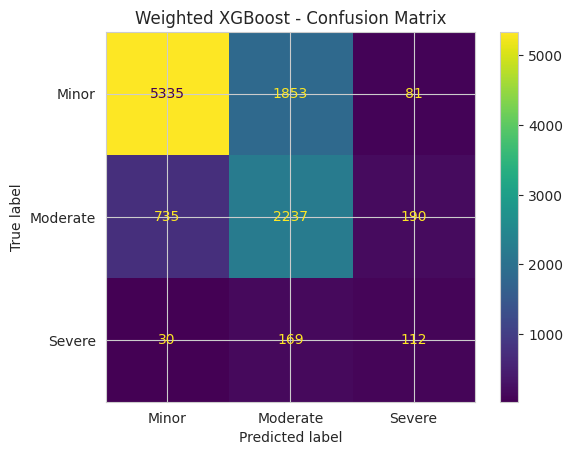

In [83]:
# ============================================
# Weighted XGBoost - Confusion Matrix
# ============================================

cm_xgb_weighted = confusion_matrix(
    y_test,
    y_pred_xgb_weighted
)

print("Confusion Matrix:")
print(cm_xgb_weighted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb_weighted,
    display_labels=label_encoder_w.classes_
)

disp.plot()
plt.title("Weighted XGBoost - Confusion Matrix")
plt.show()

In [84]:
# ============================================
# Weighted CatBoost
# ============================================

from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# --------------------------------------------
# Calculate class weights from ORIGINAL
# training data
# --------------------------------------------

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

# Convert to CatBoost format
class_weights_dict = {
    str(classes[i]): class_weights_array[i]
    for i in range(len(classes))
}

print("Class weights:")
for class_name, weight in class_weights_dict.items():
    print(f"{class_name}: {weight:.4f}")

# --------------------------------------------
# Create weighted CatBoost
# --------------------------------------------

catboost_weighted = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function="MultiClass",
    eval_metric="TotalF1",
    class_weights=class_weights_dict,
    random_seed=42,
    verbose=100
)

# --------------------------------------------
# Train on ORIGINAL training data
# --------------------------------------------

catboost_weighted.fit(
    X_train_imputed,
    y_train
)

# --------------------------------------------
# Predict on untouched test data
# --------------------------------------------

y_pred_cat_weighted = catboost_weighted.predict(
    X_test_imputed
)

# CatBoost returns a 2D array
y_pred_cat_weighted = y_pred_cat_weighted.ravel()

# --------------------------------------------
# Evaluation
# --------------------------------------------

accuracy_cat_weighted = accuracy_score(
    y_test,
    y_pred_cat_weighted
)

precision_cat_weighted = precision_score(
    y_test,
    y_pred_cat_weighted,
    average="macro",
    zero_division=0
)

recall_cat_weighted = recall_score(
    y_test,
    y_pred_cat_weighted,
    average="macro",
    zero_division=0
)

f1_cat_weighted = f1_score(
    y_test,
    y_pred_cat_weighted,
    average="macro",
    zero_division=0
)

print("\nWeighted CatBoost Results")
print("=" * 50)
print(f"Accuracy : {accuracy_cat_weighted:.4f}")
print(f"Precision: {precision_cat_weighted:.4f}")
print(f"Recall   : {recall_cat_weighted:.4f}")
print(f"Macro F1 : {f1_cat_weighted:.4f}")

print("\nClassification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_cat_weighted,
    zero_division=0
))

Class weights:
Minor: 0.4926
Moderate: 1.1324
Severe: 11.5224
0:	learn: 0.5679146	total: 103ms	remaining: 51.3s
100:	learn: 0.6780034	total: 6.42s	remaining: 25.4s
200:	learn: 0.7132242	total: 12.3s	remaining: 18.2s
300:	learn: 0.7441442	total: 19.6s	remaining: 13s
400:	learn: 0.7721894	total: 26.7s	remaining: 6.58s
499:	learn: 0.7942374	total: 31s	remaining: 0us

Weighted CatBoost Results
Accuracy : 0.6957
Precision: 0.5466
Recall   : 0.6525
Macro F1 : 0.5694

Classification Report
              precision    recall  f1-score   support

       Minor       0.89      0.71      0.79      7269
    Moderate       0.51      0.69      0.59      3162
      Severe       0.24      0.57      0.34       311

    accuracy                           0.70     10742
   macro avg       0.55      0.65      0.57     10742
weighted avg       0.76      0.70      0.71     10742



Confusion Matrix:
[[5127 1959  183]
 [ 612 2170  380]
 [  21  114  176]]


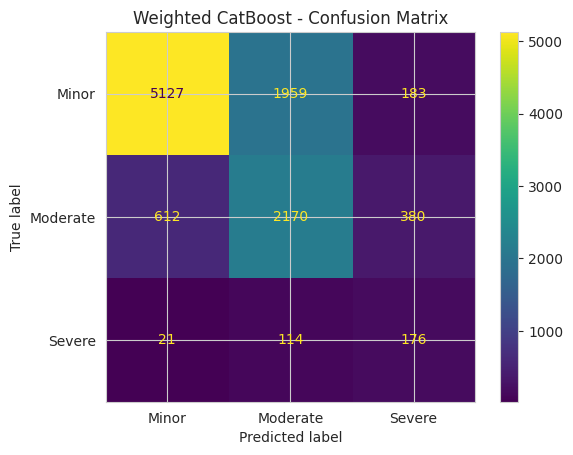

In [85]:
# ============================================
# Weighted CatBoost - Confusion Matrix
# ============================================

cm_cat_weighted = confusion_matrix(
    y_test,
    y_pred_cat_weighted
)

print("Confusion Matrix:")
print(cm_cat_weighted)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cat_weighted,
    display_labels=catboost_weighted.classes_
)

disp.plot()
plt.title("Weighted CatBoost - Confusion Matrix")
plt.show()

weighted is better than smote.
I will hypertune both according to these findings.

In [86]:
# ============================================
# Hyperparameter Tuning - Weighted XGBoost
# ============================================

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from xgboost import XGBClassifier

# --------------------------------------------
# Use the ORIGINAL training data
# --------------------------------------------

# Encode training labels
label_encoder_tune = LabelEncoder()

y_train_encoded = label_encoder_tune.fit_transform(y_train)

# Calculate balanced sample weights
sample_weights_tune = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

# --------------------------------------------
# Base XGBoost model
# --------------------------------------------

xgb_tune = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# --------------------------------------------
# Parameter grid
# --------------------------------------------

param_grid_xgb = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth": [5, 7]
}

# --------------------------------------------
# Cross-validation
# --------------------------------------------

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Macro-F1 scorer
macro_f1_scorer = make_scorer(
    f1_score,
    average="macro"
)

# --------------------------------------------
# Grid Search
# --------------------------------------------

xgb_grid = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid_xgb,
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# --------------------------------------------
# Run tuning
# --------------------------------------------

print("Starting XGBoost hyperparameter tuning...")
print("8 parameter combinations × 3 folds = 24 training runs")

xgb_grid.fit(
    X_train_imputed,
    y_train_encoded,
    sample_weight=sample_weights_tune
)

# --------------------------------------------
# Best parameters
# --------------------------------------------

print("\n" + "=" * 60)
print("BEST XGBOOST PARAMETERS")
print("=" * 60)

print("Best parameters:")
print(xgb_grid.best_params_)

print("\nBest cross-validation Macro F1:")
print(f"{xgb_grid.best_score_:.4f}")

Starting XGBoost hyperparameter tuning...
8 parameter combinations × 3 folds = 24 training runs
Fitting 3 folds for each of 8 candidates, totalling 24 fits

BEST XGBOOST PARAMETERS
Best parameters:
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500}

Best cross-validation Macro F1:
0.5535


In [87]:
# ============================================
# Final Tuned Weighted XGBoost
# ============================================

best_xgb = XGBClassifier(
    n_estimators=xgb_grid.best_params_["n_estimators"],
    learning_rate=xgb_grid.best_params_["learning_rate"],
    max_depth=xgb_grid.best_params_["max_depth"],
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

# Train final model on ALL available training data
# using the class weights
best_xgb.fit(
    X_train_imputed,
    y_train_encoded,
    sample_weight=sample_weights_tune
)

# Final prediction on untouched test set
y_pred_best_xgb_encoded = best_xgb.predict(X_test_imputed)

# Convert predictions back to class names
y_pred_best_xgb = label_encoder_tune.inverse_transform(
    y_pred_best_xgb_encoded.astype(int)
)

# ============================================
# Final Test Evaluation
# ============================================

accuracy_best_xgb = accuracy_score(
    y_test,
    y_pred_best_xgb
)

precision_best_xgb = precision_score(
    y_test,
    y_pred_best_xgb,
    average="macro",
    zero_division=0
)

recall_best_xgb = recall_score(
    y_test,
    y_pred_best_xgb,
    average="macro",
    zero_division=0
)

f1_best_xgb = f1_score(
    y_test,
    y_pred_best_xgb,
    average="macro",
    zero_division=0
)

print("\nFINAL TUNED XGBOOST")
print("=" * 50)
print(f"Accuracy : {accuracy_best_xgb:.4f}")
print(f"Precision: {precision_best_xgb:.4f}")
print(f"Recall   : {recall_best_xgb:.4f}")
print(f"Macro F1 : {f1_best_xgb:.4f}")

print("\nClassification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_best_xgb,
    zero_division=0
))


FINAL TUNED XGBOOST
Accuracy : 0.7153
Precision: 0.5641
Recall   : 0.6005
Macro F1 : 0.5746

Classification Report
              precision    recall  f1-score   support

       Minor       0.87      0.73      0.80      7269
    Moderate       0.53      0.71      0.60      3162
      Severe       0.29      0.36      0.32       311

    accuracy                           0.72     10742
   macro avg       0.56      0.60      0.57     10742
weighted avg       0.75      0.72      0.73     10742



In [88]:
# ============================================
# Hyperparameter Tuning - Weighted CatBoost
# ============================================

from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score
from sklearn.utils.class_weight import compute_sample_weight

# --------------------------------------------
# Encode target for consistent CV
# --------------------------------------------

label_encoder_cat_tune = LabelEncoder()

y_train_cat_encoded = label_encoder_cat_tune.fit_transform(y_train)

# Calculate balanced sample weights
sample_weights_cat = compute_sample_weight(
    class_weight="balanced",
    y=y_train_cat_encoded
)

# --------------------------------------------
# Base CatBoost model
# --------------------------------------------

cat_tune = CatBoostClassifier(
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

# --------------------------------------------
# Small parameter grid
# --------------------------------------------

param_grid_cat = {
    "iterations": [300, 500],
    "learning_rate": [0.03, 0.05],
    "depth": [6, 8]
}

# --------------------------------------------
# 3-fold stratified CV
# --------------------------------------------

cv_cat = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

macro_f1_scorer_cat = make_scorer(
    f1_score,
    average="macro"
)

# --------------------------------------------
# Grid Search
# --------------------------------------------

cat_grid = GridSearchCV(
    estimator=cat_tune,
    param_grid=param_grid_cat,
    scoring=macro_f1_scorer_cat,
    cv=cv_cat,
    n_jobs=-1,
    verbose=2
)

print("Starting CatBoost hyperparameter tuning...")
print("8 parameter combinations × 3 folds = 24 training runs")

# IMPORTANT:
# Fit on ORIGINAL training data with balanced weights.
cat_grid.fit(
    X_train_imputed,
    y_train_cat_encoded,
    sample_weight=sample_weights_cat
)

# --------------------------------------------
# Best parameters
# --------------------------------------------

print("\n" + "=" * 60)
print("BEST CATBOOST PARAMETERS")
print("=" * 60)

print("Best parameters:")
print(cat_grid.best_params_)

print("\nBest cross-validation Macro F1:")
print(f"{cat_grid.best_score_:.4f}")

Starting CatBoost hyperparameter tuning...
8 parameter combinations × 3 folds = 24 training runs
Fitting 3 folds for each of 8 candidates, totalling 24 fits

BEST CATBOOST PARAMETERS
Best parameters:
{'depth': 8, 'iterations': 500, 'learning_rate': 0.05}

Best cross-validation Macro F1:
0.5604


In [89]:
# ============================================
# Final Tuned Weighted CatBoost
# ============================================

best_cat = CatBoostClassifier(
    iterations=cat_grid.best_params_["iterations"],
    learning_rate=cat_grid.best_params_["learning_rate"],
    depth=cat_grid.best_params_["depth"],
    loss_function="MultiClass",
    eval_metric="TotalF1",
    random_seed=42,
    verbose=100
)

# Train on the full ORIGINAL training data
# with balanced sample weights
best_cat.fit(
    X_train_imputed,
    y_train,
    sample_weight=sample_weights_cat
)

# Predict on untouched test set
y_pred_best_cat = best_cat.predict(X_test_imputed)

# CatBoost returns a 2D array
y_pred_best_cat = y_pred_best_cat.ravel()

# ============================================
# Final Test Evaluation
# ============================================

accuracy_best_cat = accuracy_score(
    y_test,
    y_pred_best_cat
)

precision_best_cat = precision_score(
    y_test,
    y_pred_best_cat,
    average="macro",
    zero_division=0
)

recall_best_cat = recall_score(
    y_test,
    y_pred_best_cat,
    average="macro",
    zero_division=0
)

f1_best_cat = f1_score(
    y_test,
    y_pred_best_cat,
    average="macro",
    zero_division=0
)

print("\nFINAL TUNED CATBOOST")
print("=" * 50)
print(f"Accuracy : {accuracy_best_cat:.4f}")
print(f"Precision: {precision_best_cat:.4f}")
print(f"Recall   : {recall_best_cat:.4f}")
print(f"Macro F1 : {f1_best_cat:.4f}")

print("\nClassification Report")
print("=" * 50)

print(classification_report(
    y_test,
    y_pred_best_cat,
    zero_division=0
))

0:	learn: 0.5783932	total: 120ms	remaining: 59.7s
100:	learn: 0.6993169	total: 21.5s	remaining: 1m 24s
200:	learn: 0.7374103	total: 34.9s	remaining: 52s
300:	learn: 0.7803529	total: 48.5s	remaining: 32.1s
400:	learn: 0.8112424	total: 1m 2s	remaining: 15.3s
499:	learn: 0.8304130	total: 1m 15s	remaining: 0us

FINAL TUNED CATBOOST
Accuracy : 0.7043
Precision: 0.5570
Recall   : 0.6334
Macro F1 : 0.5772

Classification Report
              precision    recall  f1-score   support

       Minor       0.89      0.71      0.79      7269
    Moderate       0.52      0.71      0.60      3162
      Severe       0.27      0.48      0.34       311

    accuracy                           0.70     10742
   macro avg       0.56      0.63      0.58     10742
weighted avg       0.76      0.70      0.72     10742



# The Finale

FINAL MODEL — TUNED WEIGHTED CATBOOST
Accuracy     : 0.7043
Macro Precision: 0.5570
Macro Recall : 0.6334
Macro F1     : 0.5772

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Minor       0.89      0.71      0.79      7269
    Moderate       0.52      0.71      0.60      3162
      Severe       0.27      0.48      0.34       311

    accuracy                           0.70     10742
   macro avg       0.56      0.63      0.58     10742
weighted avg       0.76      0.70      0.72     10742


CONFUSION MATRIX
                 Predicted Minor  Predicted Moderate  Predicted Severe
Actual Minor                5175                1963               131
Actual Moderate              647                2242               273
Actual Severe                 24                 138               149


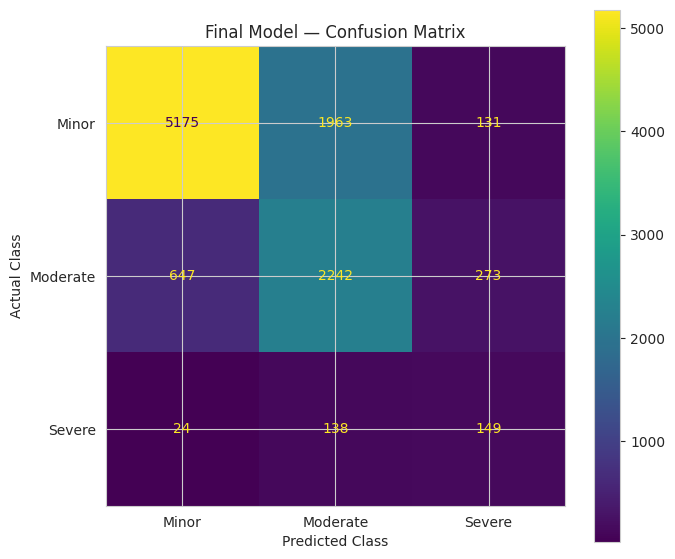

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ------------------------------------------------------------
# 1. Final predictions
# ------------------------------------------------------------

# best_cat was trained in the previous step
y_pred_final = best_cat.predict(X_test_imputed)

# CatBoost may return a 2D array
y_pred_final = np.asarray(y_pred_final).ravel()

# ------------------------------------------------------------
# 2. Overall metrics
# ------------------------------------------------------------

accuracy_final = accuracy_score(y_test, y_pred_final)

precision_final = precision_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)

recall_final = recall_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)

f1_final = f1_score(
    y_test,
    y_pred_final,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("FINAL MODEL — TUNED WEIGHTED CATBOOST")
print("=" * 60)

print(f"Accuracy     : {accuracy_final:.4f}")
print(f"Macro Precision: {precision_final:.4f}")
print(f"Macro Recall : {recall_final:.4f}")
print(f"Macro F1     : {f1_final:.4f}")

# ------------------------------------------------------------
# 3. Classification report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_final,
        labels=["Minor", "Moderate", "Severe"],
        zero_division=0
    )
)

# ------------------------------------------------------------
# 4. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=["Minor", "Moderate", "Severe"]
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(pd.DataFrame(
    cm,
    index=["Actual Minor", "Actual Moderate", "Actual Severe"],
    columns=["Predicted Minor", "Predicted Moderate", "Predicted Severe"]
))

# ------------------------------------------------------------
# 5. Plot confusion matrix
# ------------------------------------------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Minor", "Moderate", "Severe"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title("Final Model — Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [94]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import pandas as pd

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def evaluate_model(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    }


# ============================================================
# IMPORTANT:
# Use ONLY predictions that actually exist in the notebook.
# ============================================================

results = []


# ------------------------------------------------------------
# Final Tuned XGBoost
# ------------------------------------------------------------

results.append(
    evaluate_model(
        "Tuned Weighted XGBoost",
        y_test,
        y_pred_best_xgb
    )
)


# ------------------------------------------------------------
# Final Tuned CatBoost
# ------------------------------------------------------------

results.append(
    evaluate_model(
        "Tuned Weighted CatBoost",
        y_test,
        y_pred_best_cat
    )
)


# ============================================================
# Create comparison table
# ============================================================

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)


# ============================================================
# Display
# ============================================================

print("=" * 80)
print("FINAL TUNED MODEL COMPARISON")
print("=" * 80)

display(
    comparison_df.style.format({
        "Accuracy": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Macro Recall": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

FINAL TUNED MODEL COMPARISON


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Tuned Weighted CatBoost,0.7043,0.5570,0.6334,0.5772
1,Tuned Weighted XGBoost,0.7153,0.5641,0.6005,0.5746
